In [43]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [44]:
import os
print(os.path.exists(r"C:\Users\DELL\OneDrive\Desktop\New folder (3)\IMDb Movies India.csv"))


True


In [45]:
df = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\New folder (3)\IMDb Movies India.csv", encoding='latin1')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [47]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [48]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

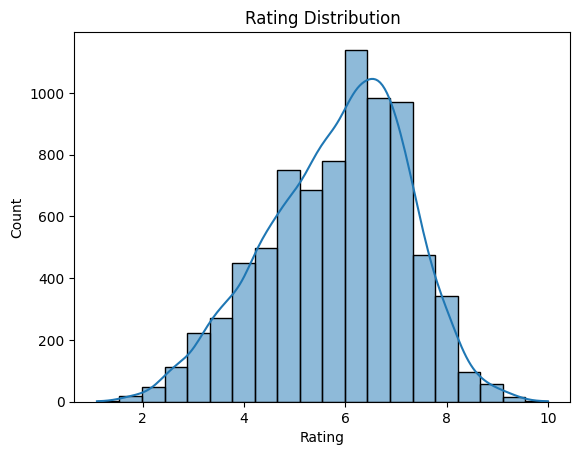

In [49]:
# Rating distribution
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title("Rating Distribution")
plt.show()

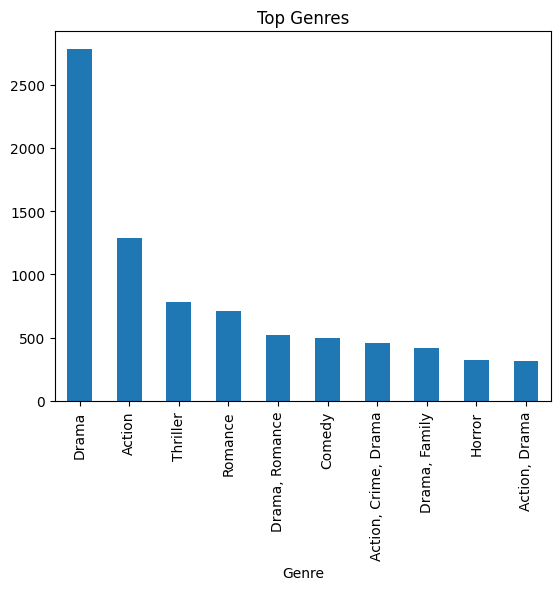

In [50]:
# Top Genres
df['Genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()

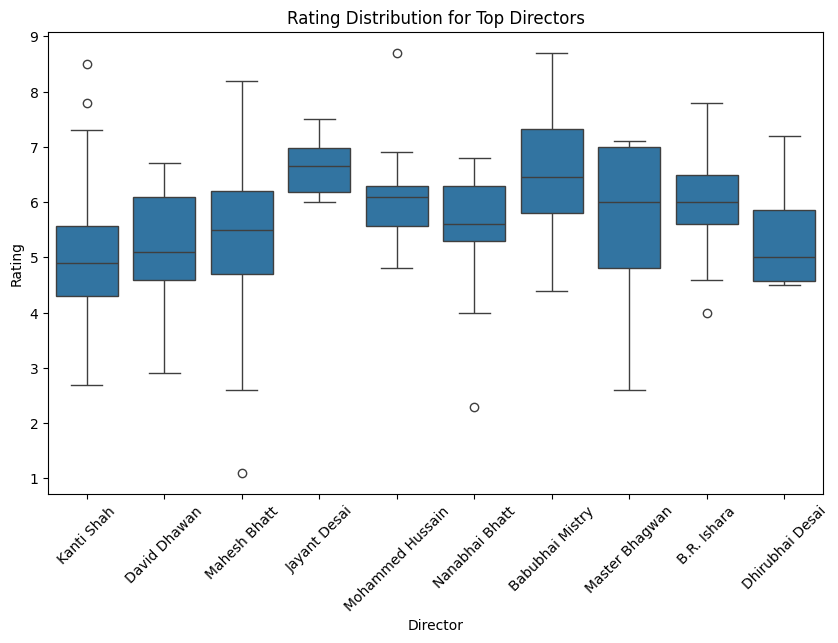

In [51]:
# Get top 10 directors
top_directors = df['Director'].value_counts().head(10).index

# Filter dataset
df_top = df[df['Director'].isin(top_directors)]

# Box plot
plt.figure(figsize=(10,6))
sns.boxplot(x='Director', y='Rating', data=df_top)

plt.xticks(rotation=45)
plt.title("Rating Distribution for Top Directors")
plt.show()

In [52]:
#Data Preprocessing
#Handle Missing Values
df = df.dropna()

In [53]:
df.columns = df.columns.str.strip()

df['Actors'] = (
    df['Actor 1'].fillna('') + ' ' +
    df['Actor 2'].fillna('') + ' ' +
    df['Actor 3'].fillna('')
)
X = df[['Genre', 'Director', 'Actors']]
y = df['Rating']

In [54]:
#Encoding Categorical Data
categorical_features = ['Genre', 'Director', 'Actors']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [55]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer
preprocessor = ColumnTransformer(
    transformers=[
        ('genre', TfidfVectorizer(), 'Genre'),
        ('director', TfidfVectorizer(), 'Director'),
        ('actors', TfidfVectorizer(), 'Actors')
    ]
)

In [57]:
#Model 1: Linear Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

In [58]:
print("Linear Regression Performance:")

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Performance:
MAE: 3.2635228590780985
RMSE: 11.765788281855153
R2 Score: -73.75860612923807


In [59]:
#Model 2: Random Forest Regressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

In [60]:
print("Random Forest Performance:")

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Performance:
MAE: 0.9816577444051826
RMSE: 1.2526057826704875
R2 Score: 0.1526790168511296


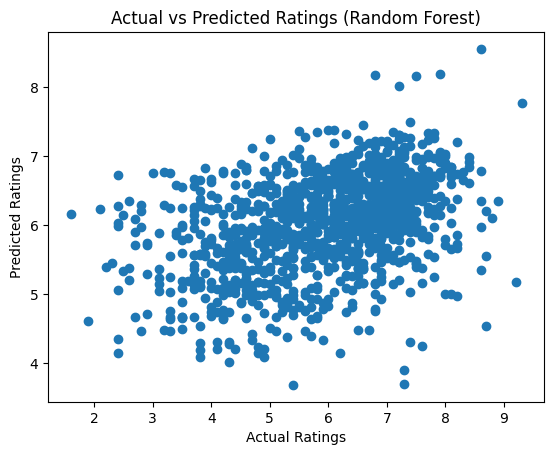

In [61]:
#Actual vs Predicted Visualization
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings (Random Forest)")
plt.show()

In [62]:
sample = pd.DataFrame({
    'Genre': ['Action'],
    'Director': ['Christopher Nolan'],
    'Actors': ['Leonardo DiCaprio']
})

predicted_rating = rf_pipeline.predict(sample)
print("Predicted Rating:", predicted_rating[0])

Predicted Rating: 5.1480000000000015


In [64]:
print("MOVIE RATING PREDICTION COMPLETED ")

MOVIE RATING PREDICTION COMPLETED 
